In [1]:
# Data Preparation & Preprocessing

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

# 2. Load Datasets

In [3]:
customers = pd.read_excel("customers.xlsx")
orders = pd.read_excel("Orders.xlsx")
restaurants = pd.read_excel("Restaurants.xlsx")
delivery = pd.read_excel("Delivery_Partners.xlsx")

# 3. Dataset Overview

In [4]:
customers.head()

,Customer_ID,Gender,Age_Group,City,Customer_Type,Total_Orders,Average_Spend,Preferred_Cuisine
0,C00001,Female,36-50,Urban,New,1,375,Italian
1,C00002,Female,36-50,Urban,New,2,320,Italian
2,C00003,Female,36-50,Metropolitian,New,2,450,North Indian
3,C00004,Female,26-35,Urban,New,2,140,South Indian
4,C00005,Male,18-25,Urban,New,1,282,North Indian


In [5]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Restaurant_ID,Region,Delivery_Partner_ID,Order_Value,Delivery_Fee,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Delivery_Time_Minutes,Order_Rating,Festival_Flag
0,O809577,2025-04-12,C01162,R282,Metropolitian,D0496,423,30,0,453,Card,Delivered,40,4,False
1,O613973,2023-01-14,C05894,R181,Semi-Urban,D0624,416,30,0,446,Wallet,Delivered,32,4,False
2,O133055,2024-05-29,C02487,R303,Semi-Urban,D0044,465,50,0,515,UPI,Returned,34,4,False
3,O721755,2025-09-09,C01639,R409,Semi-Urban,D0988,345,30,75,300,Cash,Delivered,36,3,False
4,O566596,2024-11-01,C05141,R358,Semi-Urban,D1087,611,30,30,611,Card,Delivered,31,3,True


In [6]:
restaurants.head()

,Restaurant_ID,City,Avg_Preparation_Time_Minutes,Avg_Rating,Order_Capacity_Per_Day,Restaurant_Name,Cuisine_Type
0,R001,Metropolitian,27,4.64,114,Restaurant_900,Fast Food
1,R002,Semi-Urban,40,4.10,1,Restaurant_1003,Italian
2,R003,Urban,24,4.71,30,Restaurant_671,Indian
3,R004,Urban,23,4.71,32,Restaurant_620,Fast Food
4,R005,Urban,25,4.72,28,Restaurant_926,Fast Food


In [7]:
delivery.head()

,Delivery_Partner_ID,Partner_Name,Vehicle_Type,Avg_Delivery_Speed_KMPH,Successful_Deliveries,Delayed_Deliveries,Avg_Customer_Rating,Region,Delivery_Efficiency_Score
0,D0001,Arjun Sharma,Scooter,23.310805,42,5,4.634091,Metropolitian,0.810
1,D0002,Vikram Gupta,Bike,21.378411,25,4,4.644444,Metropolitian,0.784
2,D0003,Vikram Chopra,Bike,16.008422,8,1,4.637500,Urban,0.754
3,D0004,Kiran Sharma,Bike,15.686597,9,0,4.650000,Urban,0.797
4,D0005,Arjun Sharma,Scooter,24.361525,5,0,4.460000,Metropolitian,0.850


In [8]:
print("Customers :", customers.shape)
print("Orders :", orders.shape)
print("Restaurants :", restaurants.shape)
print("Delivery Partners :", delivery.shape)

Customers : (22000, 8)
Orders : (100000, 15)
Restaurants : (550, 7)
Delivery Partners : (1100, 9)


In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer_ID        22000 non-null  object
 1   Gender             22000 non-null  object
 2   Age_Group          22000 non-null  object
 3   City               22000 non-null  object
 4   Customer_Type      22000 non-null  object
 5   Total_Orders       22000 non-null  int64 
 6   Average_Spend      22000 non-null  int64 
 7   Preferred_Cuisine  22000 non-null  object
dtypes: int64(2), object(6)
memory usage: 1.3+ MB


In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Order_ID               100000 non-null  object        
 1   Order_Date             100000 non-null  datetime64[ns]
 2   Customer_ID            100000 non-null  object        
 3   Restaurant_ID          100000 non-null  object        
 4   Region                 100000 non-null  object        
 5   Delivery_Partner_ID    100000 non-null  object        
 6   Order_Value            100000 non-null  int64         
 7   Delivery_Fee           100000 non-null  int64         
 8   Discount_Applied       100000 non-null  int64         
 9   Final_Amount           100000 non-null  int64         
 10  Payment_Mode           100000 non-null  object        
 11  Order_Status           100000 non-null  object        
 12  Delivery_Time_Minutes  100000 non-null  int64

In [11]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Restaurant_ID                 550 non-null    object 
 1   City                          550 non-null    object 
 2   Avg_Preparation_Time_Minutes  550 non-null    int64  
 3   Avg_Rating                    452 non-null    float64
 4   Order_Capacity_Per_Day        550 non-null    int64  
 5   Restaurant_Name               550 non-null    object 
 6   Cuisine_Type                  550 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 30.2+ KB


In [12]:
delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delivery_Partner_ID        1100 non-null   object 
 1   Partner_Name               1100 non-null   object 
 2   Vehicle_Type               1100 non-null   object 
 3   Avg_Delivery_Speed_KMPH    1100 non-null   float64
 4   Successful_Deliveries      1100 non-null   int64  
 5   Delayed_Deliveries         1100 non-null   int64  
 6   Avg_Customer_Rating        1093 non-null   float64
 7   Region                     1100 non-null   object 
 8   Delivery_Efficiency_Score  1093 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 77.5+ KB


# 4. Missing Value Analysis

In [13]:
customers.isnull().sum()

Customer_ID          0
Gender               0
Age_Group            0
City                 0
Customer_Type        0
Total_Orders         0
Average_Spend        0
Preferred_Cuisine    0
dtype: int64

In [14]:
orders.isnull().sum()

Order_ID                 0
Order_Date               0
Customer_ID              0
Restaurant_ID            0
Region                   0
Delivery_Partner_ID      0
Order_Value              0
Delivery_Fee             0
Discount_Applied         0
Final_Amount             0
Payment_Mode             0
Order_Status             0
Delivery_Time_Minutes    0
Order_Rating             0
Festival_Flag            0
dtype: int64

In [15]:
restaurants.isnull().sum()

Restaurant_ID                    0
City                             0
Avg_Preparation_Time_Minutes     0
Avg_Rating                      98
Order_Capacity_Per_Day           0
Restaurant_Name                  0
Cuisine_Type                     0
dtype: int64

In [16]:
delivery.isnull().sum()

Delivery_Partner_ID          0
Partner_Name                 0
Vehicle_Type                 0
Avg_Delivery_Speed_KMPH      0
Successful_Deliveries        0
Delayed_Deliveries           0
Avg_Customer_Rating          7
Region                       0
Delivery_Efficiency_Score    7
dtype: int64

In [17]:
# Calculate percentage of missing value

def missing_value_report(df):

    report = pd.DataFrame({
        "Column Name": df.columns,
        "Missing Values": df.isnull().sum().values,
        "Missing %": df.isnull().sum().values / len(df) * 100
    })
    return report

In [18]:
customer_missing = missing_value_report(customers)
customer_missing

,Column Name,Missing Values,Missing %
0,Customer_ID,0,0.0
1,Gender,0,0.0
2,Age_Group,0,0.0
3,City,0,0.0
4,Customer_Type,0,0.0
5,Total_Orders,0,0.0
6,Average_Spend,0,0.0
7,Preferred_Cuisine,0,0.0


In [19]:
orders_missing = missing_value_report(orders)
orders_missing

,Column Name,Missing Values,Missing %
0,Order_ID,0,0.0
1,Order_Date,0,0.0
2,Customer_ID,0,0.0
3,Restaurant_ID,0,0.0
4,Region,0,0.0
5,Delivery_Partner_ID,0,0.0
6,Order_Value,0,0.0
7,Delivery_Fee,0,0.0
8,Discount_Applied,0,0.0
9,Final_Amount,0,0.0


In [20]:
restaurants_missing = missing_value_report(restaurants)
restaurants_missing

,Column Name,Missing Values,Missing %
0,Restaurant_ID,0,0.000000
1,City,0,0.000000
2,Avg_Preparation_Time_Minutes,0,0.000000
3,Avg_Rating,98,17.818182
4,Order_Capacity_Per_Day,0,0.000000
5,Restaurant_Name,0,0.000000
6,Cuisine_Type,0,0.000000


In [21]:
delivery_missing = missing_value_report(delivery)
delivery_missing

,Column Name,Missing Values,Missing %
0,Delivery_Partner_ID,0,0.000000
1,Partner_Name,0,0.000000
2,Vehicle_Type,0,0.000000
3,Avg_Delivery_Speed_KMPH,0,0.000000
4,Successful_Deliveries,0,0.000000
5,Delayed_Deliveries,0,0.000000
6,Avg_Customer_Rating,7,0.636364
7,Region,0,0.000000
8,Delivery_Efficiency_Score,7,0.636364


# 5. Duplicate Analysis

In [22]:
print("Duplicate Rows")
print("="*30)
print("Customers:", customers.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Restaurants:", restaurants.duplicated().sum())
print("Delivery Partners:", delivery.duplicated().sum())

Duplicate Rows
Customers: 0
Orders: 0
Restaurants: 0
Delivery Partners: 0


In [23]:
# Calculate percentage of Duplicate rows

def duplicate_report(df, dataset_name):

    report = pd.DataFrame({
        "Dataset": [dataset_name],
        "Total Records": [len(df)],
        "Duplicate Rows": [df.duplicated().sum()],
        "Duplicate %": [round(df.duplicated().sum() / len(df) * 100, 2)]
    })
    return report

In [24]:
customers_duplicate_report = duplicate_report(customers, "Customers")
customers_duplicate_report

,Dataset,Total Records,Duplicate Rows,Duplicate %
0,Customers,22000,0,0.0


In [25]:
orders_duplicate_report = duplicate_report(orders, "Orders")
orders_duplicate_report

,Dataset,Total Records,Duplicate Rows,Duplicate %
0,Orders,100000,0,0.0


In [26]:
restaurants_duplicate_report = duplicate_report(restaurants, "Restaurants")
restaurants_duplicate_report

,Dataset,Total Records,Duplicate Rows,Duplicate %
0,Restaurants,550,0,0.0


In [27]:
delivery_duplicate_report = duplicate_report(delivery, "Delivery Partners")
delivery_duplicate_report

,Dataset,Total Records,Duplicate Rows,Duplicate %
0,Delivery Partners,1100,0,0.0


# 6. Data Type Validation

In [28]:
print("Data Type Validation")
print("=" * 60)

print("Customers")
print("-" * 30)
print(customers.dtypes)

print("\nOrders")
print("-" * 30)
print(orders.dtypes)

print("\nRestaurants")
print("-" * 30)
print(restaurants.dtypes)

print("\nDelivery Partners")
print("-" * 30)
print(delivery.dtypes)

Data Type Validation
Customers
------------------------------
Customer_ID          object
Gender               object
Age_Group            object
City                 object
Customer_Type        object
Total_Orders          int64
Average_Spend         int64
Preferred_Cuisine    object
dtype: object

Orders
------------------------------
Order_ID                         object
Order_Date               datetime64[ns]
Customer_ID                      object
Restaurant_ID                    object
Region                           object
Delivery_Partner_ID              object
Order_Value                       int64
Delivery_Fee                      int64
Discount_Applied                  int64
Final_Amount                      int64
Payment_Mode                     object
Order_Status                     object
Delivery_Time_Minutes             int64
Order_Rating                      int64
Festival_Flag                      bool
dtype: object

Restaurants
------------------------------
Res

In [29]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer_ID        22000 non-null  object
 1   Gender             22000 non-null  object
 2   Age_Group          22000 non-null  object
 3   City               22000 non-null  object
 4   Customer_Type      22000 non-null  object
 5   Total_Orders       22000 non-null  int64 
 6   Average_Spend      22000 non-null  int64 
 7   Preferred_Cuisine  22000 non-null  object
dtypes: int64(2), object(6)
memory usage: 1.3+ MB


In [30]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Order_ID               100000 non-null  object        
 1   Order_Date             100000 non-null  datetime64[ns]
 2   Customer_ID            100000 non-null  object        
 3   Restaurant_ID          100000 non-null  object        
 4   Region                 100000 non-null  object        
 5   Delivery_Partner_ID    100000 non-null  object        
 6   Order_Value            100000 non-null  int64         
 7   Delivery_Fee           100000 non-null  int64         
 8   Discount_Applied       100000 non-null  int64         
 9   Final_Amount           100000 non-null  int64         
 10  Payment_Mode           100000 non-null  object        
 11  Order_Status           100000 non-null  object        
 12  Delivery_Time_Minutes  100000 non-null  int64

In [31]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Restaurant_ID                 550 non-null    object 
 1   City                          550 non-null    object 
 2   Avg_Preparation_Time_Minutes  550 non-null    int64  
 3   Avg_Rating                    452 non-null    float64
 4   Order_Capacity_Per_Day        550 non-null    int64  
 5   Restaurant_Name               550 non-null    object 
 6   Cuisine_Type                  550 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 30.2+ KB


In [32]:
delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Delivery_Partner_ID        1100 non-null   object 
 1   Partner_Name               1100 non-null   object 
 2   Vehicle_Type               1100 non-null   object 
 3   Avg_Delivery_Speed_KMPH    1100 non-null   float64
 4   Successful_Deliveries      1100 non-null   int64  
 5   Delayed_Deliveries         1100 non-null   int64  
 6   Avg_Customer_Rating        1093 non-null   float64
 7   Region                     1100 non-null   object 
 8   Delivery_Efficiency_Score  1093 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 77.5+ KB


# 7. Outlier Analysis - 7.1: Statistical summary

In [33]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Orders,22000.0,6.957682,11.981829,1.0,3.0,5.0,10.0,271.0
Average_Spend,22000.0,322.838591,87.904520,102.0,262.0,315.0,373.0,790.0


In [34]:
orders.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,100000,2024-07-06 23:50:34.943999744,2023-01-01 00:00:00,2023-10-10 00:00:00,2024-07-11 00:00:00,2025-04-04 00:00:00,2025-12-31 00:00:00,NaN
Order_Value,100000.0,545.67792,200.0,429.0,542.0,656.0,1200.0,167.167972
Delivery_Fee,100000.0,35.68535,30.0,30.0,35.0,40.0,55.0,6.172919
Discount_Applied,100000.0,21.41095,0.0,0.0,0.0,30.0,150.0,40.660466
Final_Amount,100000.0,559.95232,80.0,441.0,557.0,673.0,1250.0,172.104647
Delivery_Time_Minutes,100000.0,35.50556,25.0,32.0,35.0,39.0,50.0,4.914946
Order_Rating,100000.0,4.02323,1.0,4.0,4.0,5.0,5.0,0.927027


In [35]:
restaurants.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Preparation_Time_Minutes,550.0,26.923636,5.898163,20.0,22.0,26.00,29.00,40.0
Avg_Rating,452.0,4.620376,0.215836,3.5,4.6,4.64,4.70,5.0
Order_Capacity_Per_Day,550.0,32.240000,41.732305,1.0,1.0,17.00,36.75,136.0


In [36]:
delivery.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg_Delivery_Speed_KMPH,1100.0,22.301773,5.581138,5.00,19.466769,22.31473,25.088396,40.000000
Successful_Deliveries,1100.0,14.305455,13.510531,0.00,4.000000,9.00000,23.250000,49.000000
Delayed_Deliveries,1100.0,1.620909,2.079607,0.00,0.000000,1.00000,2.000000,12.000000
Avg_Customer_Rating,1093.0,4.643985,0.145824,3.70,4.583333,4.65000,4.720000,5.133333
Delivery_Efficiency_Score,1093.0,0.791236,0.116992,0.26,0.773000,0.81200,0.848000,1.000000


# 7.2: Boxplots

In [37]:
import matplotlib.pyplot as plt

In [38]:
def plot_boxplots(df, dataset_name):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        plt.figure(figsize=(6, 4))
        plt.boxplot(df[col].dropna()) # boxplot cannot use missing values, so we remove them
        plt.title(f"{dataset_name} - {col}")
        plt.ylabel(col)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()

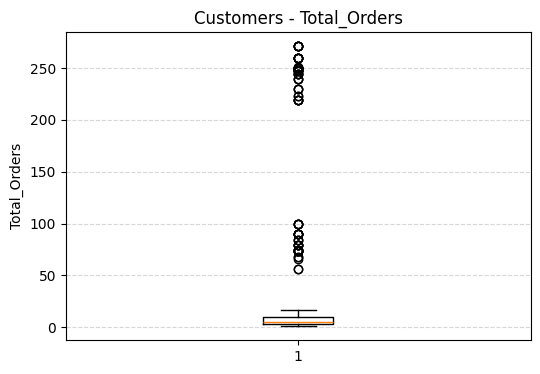

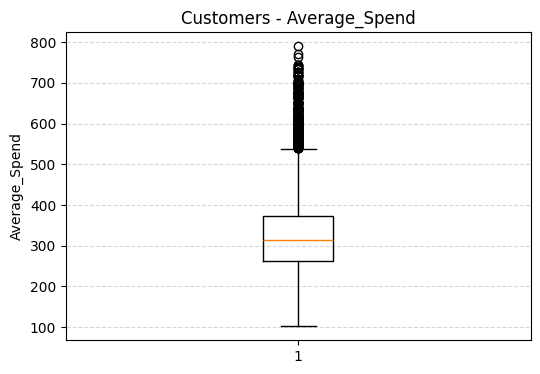

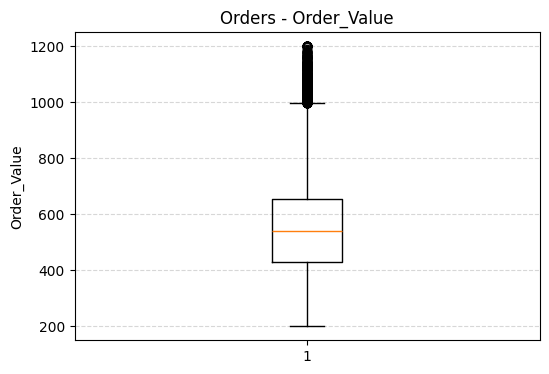

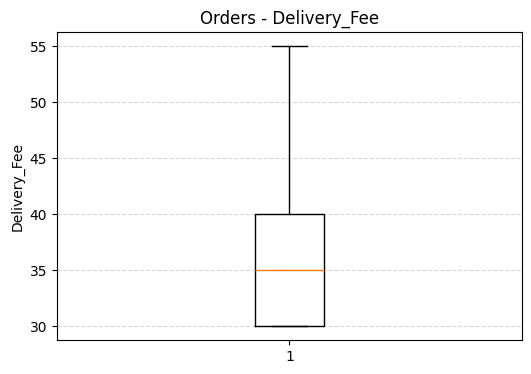

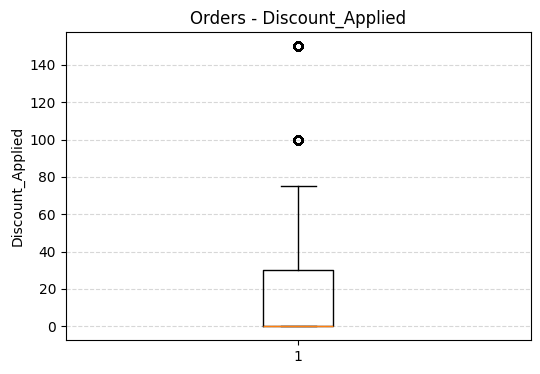

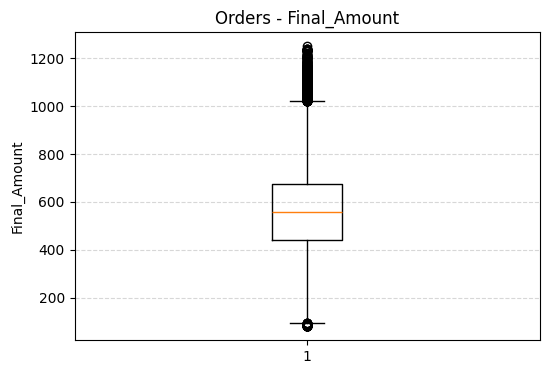

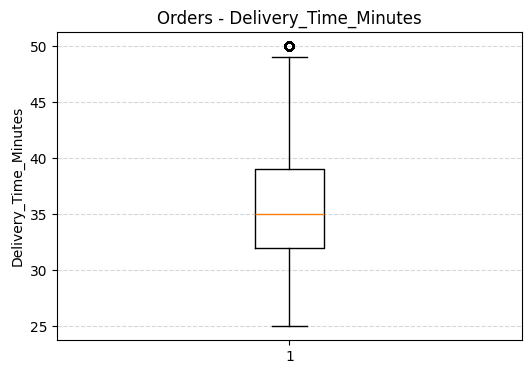

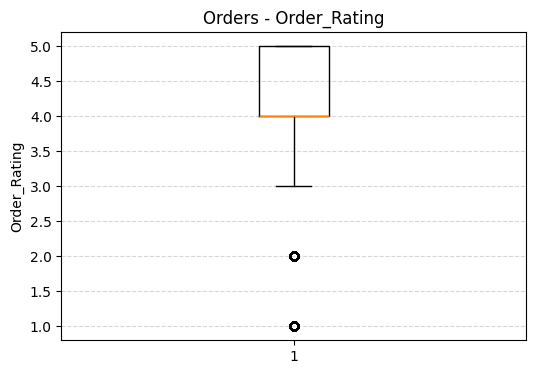

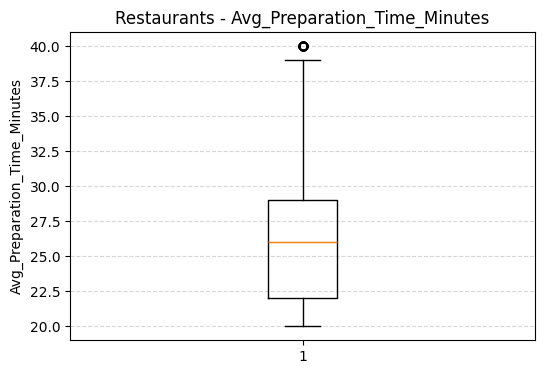

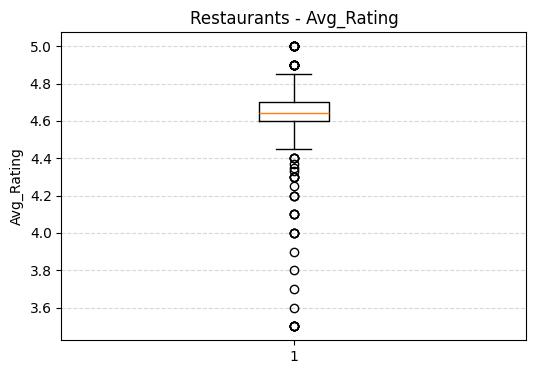

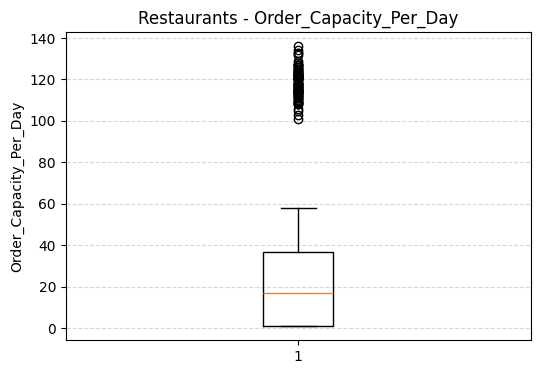

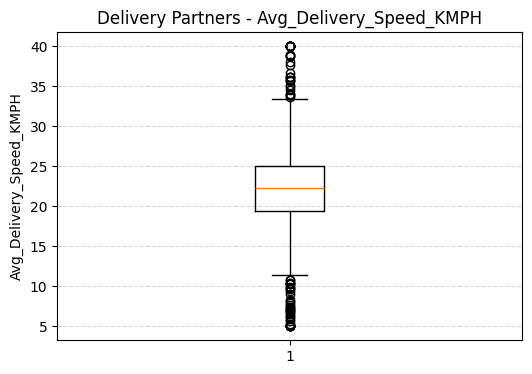

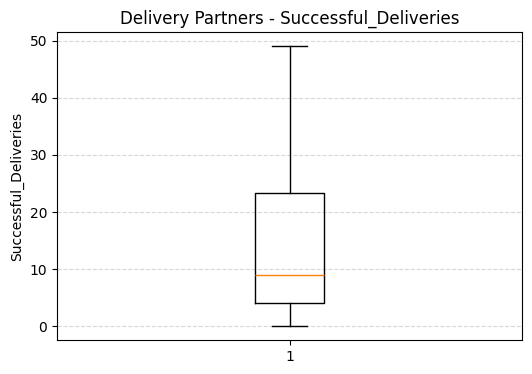

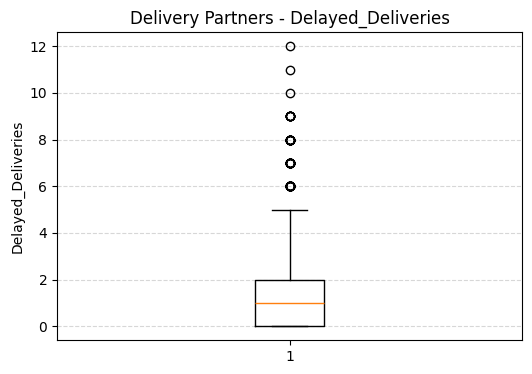

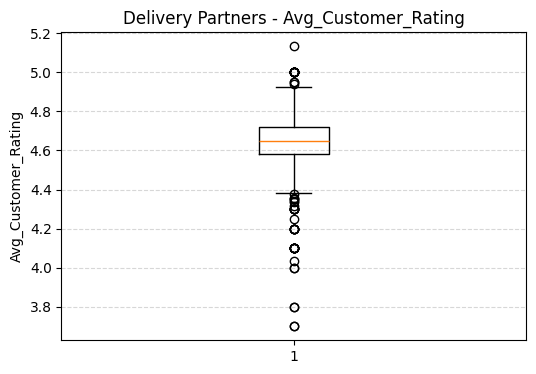

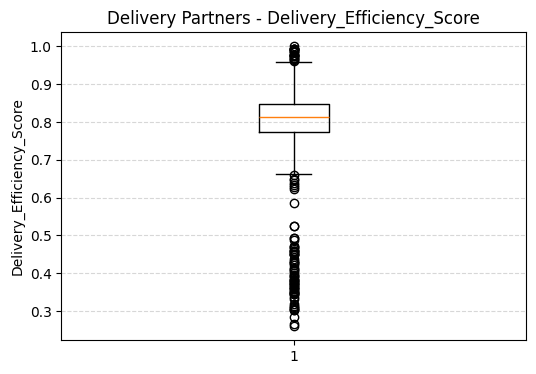

In [39]:
plot_boxplots(customers, "Customers")
plot_boxplots(orders, "Orders")
plot_boxplots(restaurants, "Restaurants")
plot_boxplots(delivery, "Delivery Partners")

# 7.3: IQR method

In [40]:
def outlier_report(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    report = []

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        report.append({
            "Column": col,
            "Outliers": outliers,
            "Outlier %": round(outliers / len(df) * 100, 2)
        })

    return pd.DataFrame(report)

In [41]:
customer_outliers = outlier_report(customers)
orders_outliers = outlier_report(orders)
restaurants_outliers = outlier_report(restaurants)
delivery_outliers = outlier_report(delivery)

In [42]:
customer_outliers

,Column,Outliers,Outlier %
0,Total_Orders,80,0.36
1,Average_Spend,376,1.71


In [43]:
orders_outliers

,Column,Outliers,Outlier %
0,Order_Value,611,0.61
1,Delivery_Fee,0,0.00
2,Discount_Applied,10097,10.10
3,Final_Amount,656,0.66
4,Delivery_Time_Minutes,258,0.26
5,Order_Rating,6970,6.97


In [44]:
restaurants_outliers

,Column,Outliers,Outlier %
0,Avg_Preparation_Time_Minutes,60,10.91
1,Avg_Rating,59,10.73
2,Order_Capacity_Per_Day,95,17.27


In [45]:
delivery_outliers

,Column,Outliers,Outlier %
0,Avg_Delivery_Speed_KMPH,71,6.45
1,Successful_Deliveries,0,0.00
2,Delayed_Deliveries,80,7.27
3,Avg_Customer_Rating,54,4.91
4,Delivery_Efficiency_Score,95,8.64


# 8. Data Cleaning plan

In [46]:
# =====================================
# Data Cleaning Plan
# =====================================

"""
Based on the data quality assessment:

1. Impute missing values in Restaurants['Avg_Rating'] using the median.
2. Filled missing values in delivery['Avg_Customer_Rating'] and ['Delivery_Efficiency_Score'] using the median
3. No duplicate rows were found.
4. No data type corrections are required.
5. No blank columns were found.
6. Outliers will be retained as they represent valid business observations.
"""

"\nBased on the data quality assessment:\n\n1. Impute missing values in Restaurants['Avg_Rating'] using the median.\n2. Filled missing values in delivery['Avg_Customer_Rating'] and ['Delivery_Efficiency_Score'] using the median\n3. No duplicate rows were found.\n4. No data type corrections are required.\n5. No blank columns were found.\n6. Outliers will be retained as they represent valid business observations.\n"

In [47]:
# Fill missing values in Restaurants ratings

restaurants["Avg_Rating"] = restaurants["Avg_Rating"].fillna(restaurants["Avg_Rating"].median())

In [48]:
# Verify

restaurants["Avg_Rating"].isnull().sum()

np.int64(0)

In [49]:
# Filled missing values of two columns using the median

delivery["Avg_Customer_Rating"] = delivery["Avg_Customer_Rating"].fillna(
    delivery["Avg_Customer_Rating"].median()
)

delivery["Delivery_Efficiency_Score"] = delivery["Delivery_Efficiency_Score"].fillna(
    delivery["Delivery_Efficiency_Score"].median()
)

In [50]:
# Verify

delivery.isnull().sum()

Delivery_Partner_ID          0
Partner_Name                 0
Vehicle_Type                 0
Avg_Delivery_Speed_KMPH      0
Successful_Deliveries        0
Delayed_Deliveries           0
Avg_Customer_Rating          0
Region                       0
Delivery_Efficiency_Score    0
dtype: int64

In [51]:
customer_missing = missing_value_report(customers)
orders_missing = missing_value_report(orders)
restaurants_missing = missing_value_report(restaurants)
delivery_missing = missing_value_report(delivery)

print("Missing Value Report")
print("="*80)
print("Customers")
print(customer_missing)
print("="*80)
print("Orders")
print(orders_missing)
print("="*80)
print("Restaurants")
print(restaurants_missing)
print("="*80)
print("Delivery_Partners")
print(delivery_missing)

Missing Value Report
Customers
         Column Name  Missing Values  Missing %
0        Customer_ID               0        0.0
1             Gender               0        0.0
2          Age_Group               0        0.0
3               City               0        0.0
4      Customer_Type               0        0.0
5       Total_Orders               0        0.0
6      Average_Spend               0        0.0
7  Preferred_Cuisine               0        0.0
Orders
              Column Name  Missing Values  Missing %
0                Order_ID               0        0.0
1              Order_Date               0        0.0
2             Customer_ID               0        0.0
3           Restaurant_ID               0        0.0
4                  Region               0        0.0
5     Delivery_Partner_ID               0        0.0
6             Order_Value               0        0.0
7            Delivery_Fee               0        0.0
8        Discount_Applied               0        0.0


# 9. Export Clean Dataset

In [52]:
customers.to_csv("customers_cleaned.csv", index=False)
orders.to_csv("orders_cleaned.csv", index=False)
restaurants.to_csv("restaurants_cleaned.csv", index=False)
delivery.to_csv("delivery_partners_cleaned.csv", index=False)

# 10. Sprint 2 Summary